In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, r2_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("C:\ESG\data\company_esg_financial_dataset.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (11000, 16)


,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [3]:
#Basic Information of Dataset
print("Dataset Info: ")
print(df.info())
print("\nMissing Values: ")
print(df.isnull().sum())
print("\nDuplicated Rows: ")
print(df.duplicated().sum())

Dataset Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: floa

In [4]:
#statistical summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CompanyID,11000.0,NaN,NaN,NaN,500.5,288.688113,1.0,250.75,500.5,750.25,1000.0
CompanyName,11000,1000,Company_1000,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industry,11000,9,Healthcare,1331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,11000,7,Asia,1672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,11000.0,NaN,NaN,NaN,2020.0,3.162421,2015.0,2017.0,2020.0,2023.0,2025.0
Revenue,11000.0,NaN,NaN,NaN,4670.850591,9969.954369,35.9,938.775,1902.3,4342.625,180810.4
ProfitMargin,11000.0,NaN,NaN,NaN,10.900455,8.758711,-20.0,5.3,10.5,16.3,50.0
MarketCap,11000.0,NaN,NaN,NaN,13380.622236,39922.870373,1.8,1098.525,3096.45,9995.5,865271.7
GrowthRate,10000.0,NaN,NaN,NaN,4.83037,9.424787,-36.0,-1.325,4.9,11.0,38.0
ESG_Overall,11000.0,NaN,NaN,NaN,54.615273,15.893937,6.3,44.1,54.6,65.6,98.8


In [5]:
#Duplicates and Data Types of Columns
print(f"Diplicated Rows: {df.duplicated().sum()}")

numerical_cols = df.select_dtypes(include=['int','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Columns: {numerical_cols}")
print(f"Categorical Columns: {categorical_cols}")

Diplicated Rows: 0
Numerical Columns: ['CompanyID', 'Year', 'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']
Categorical Columns: ['CompanyName', 'Industry', 'Region']


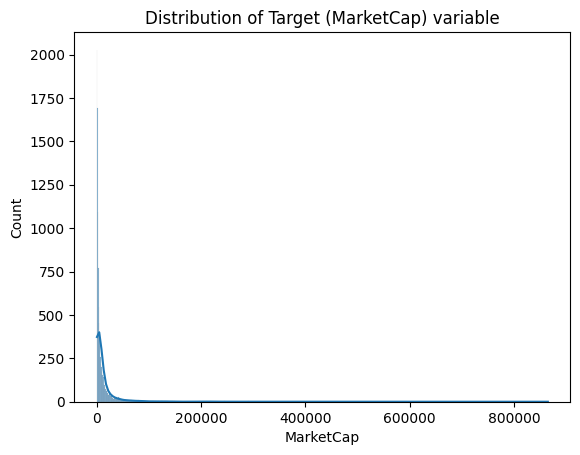

In [6]:
#distribution of target variable
sns.histplot(df['MarketCap'], kde=True)
plt.title("Distribution of Target (MarketCap) variable")
plt.show()

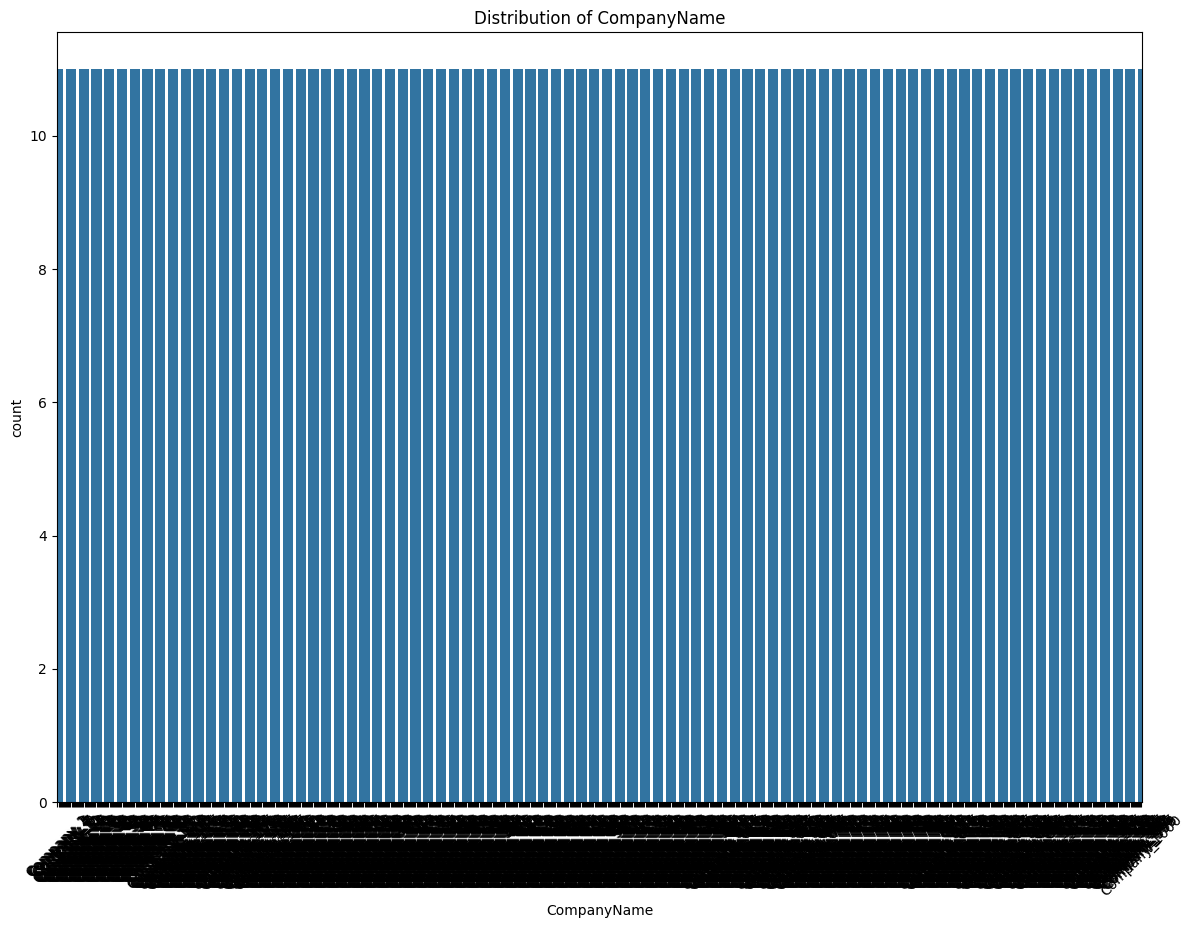

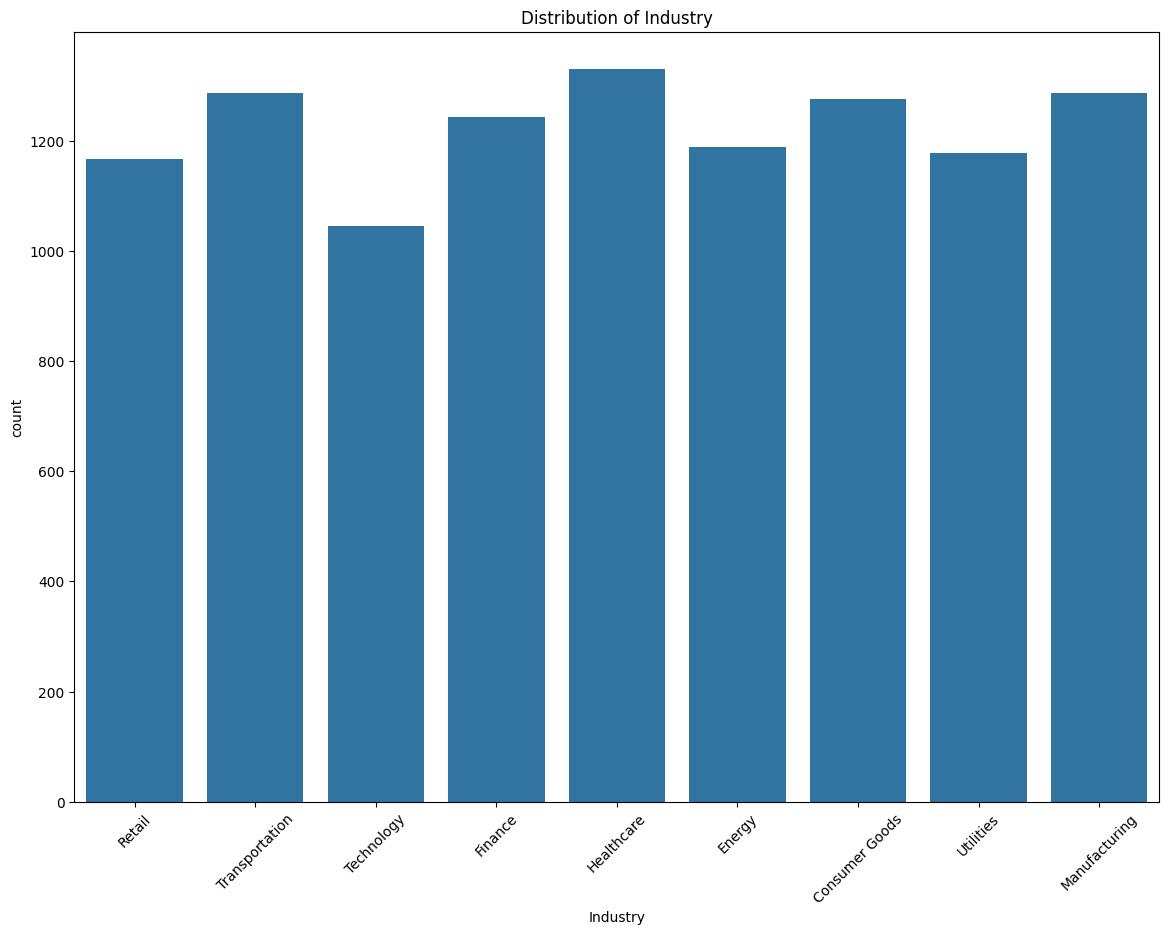

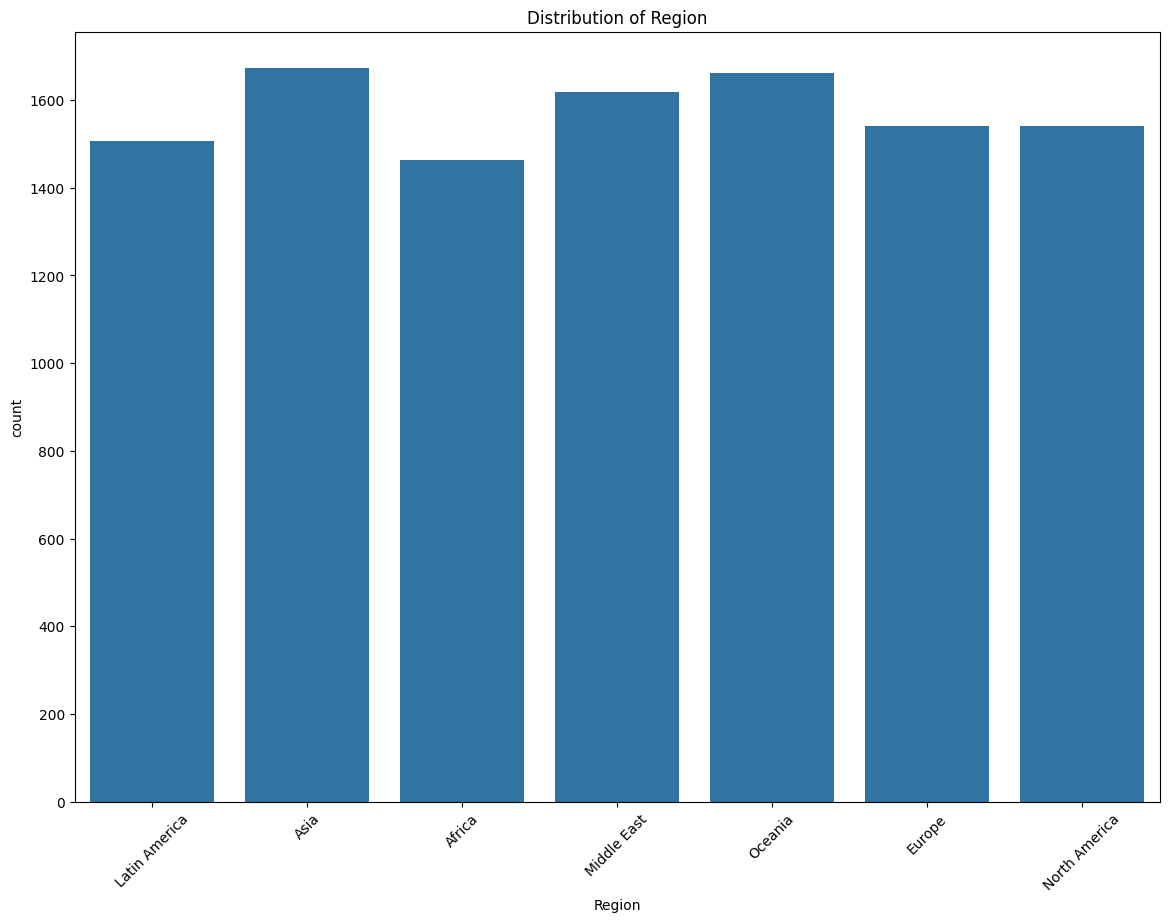

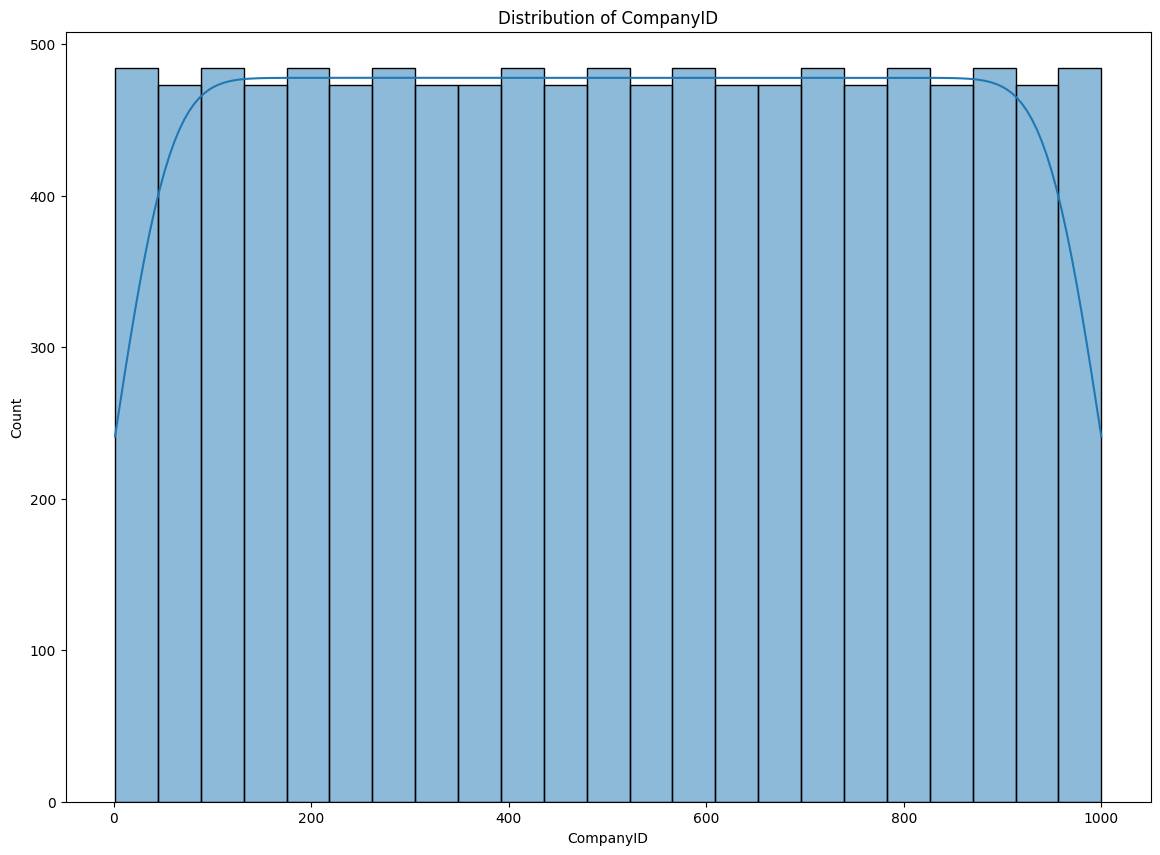

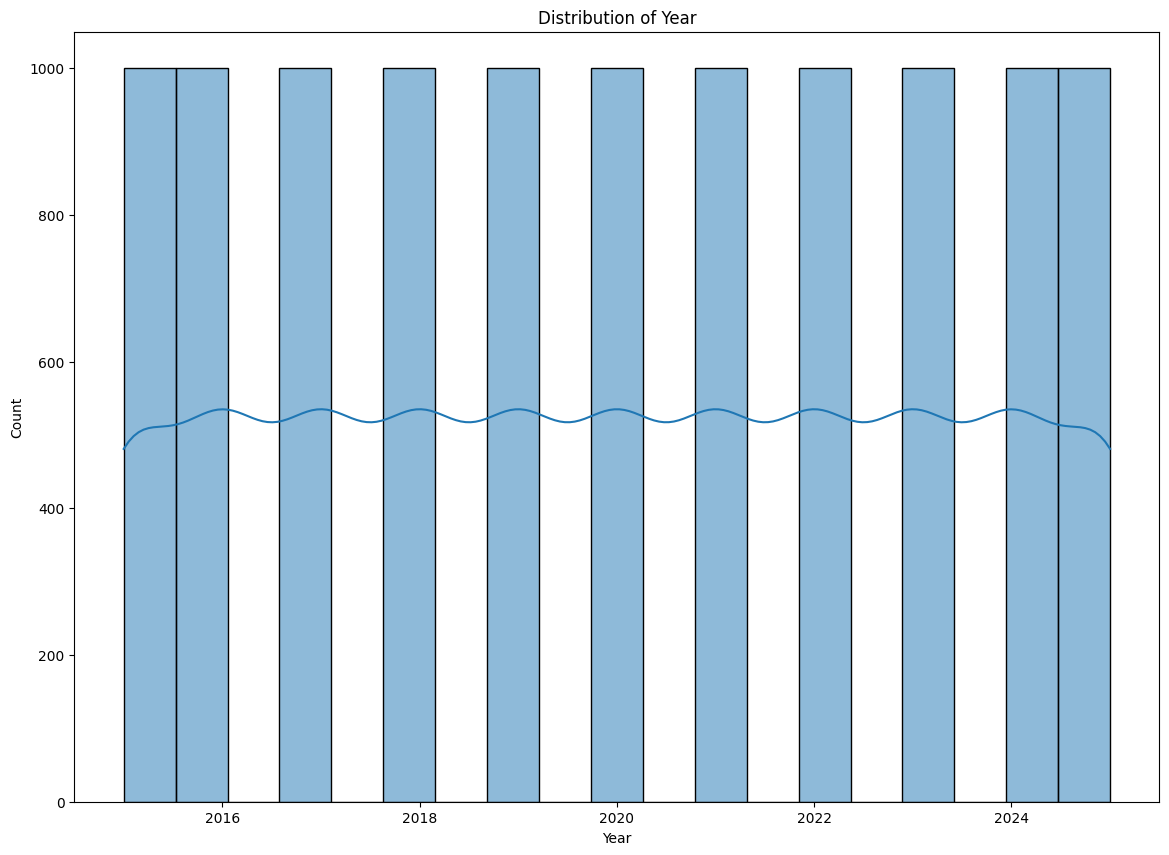

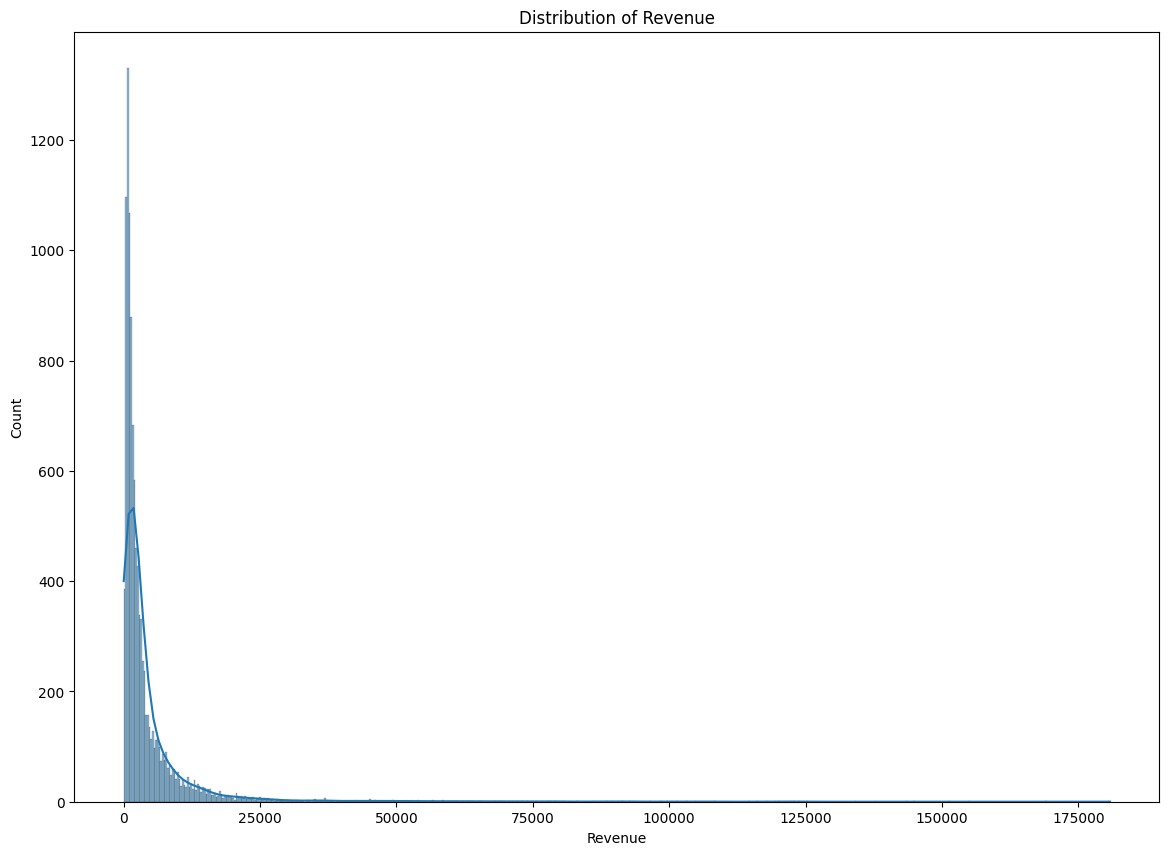

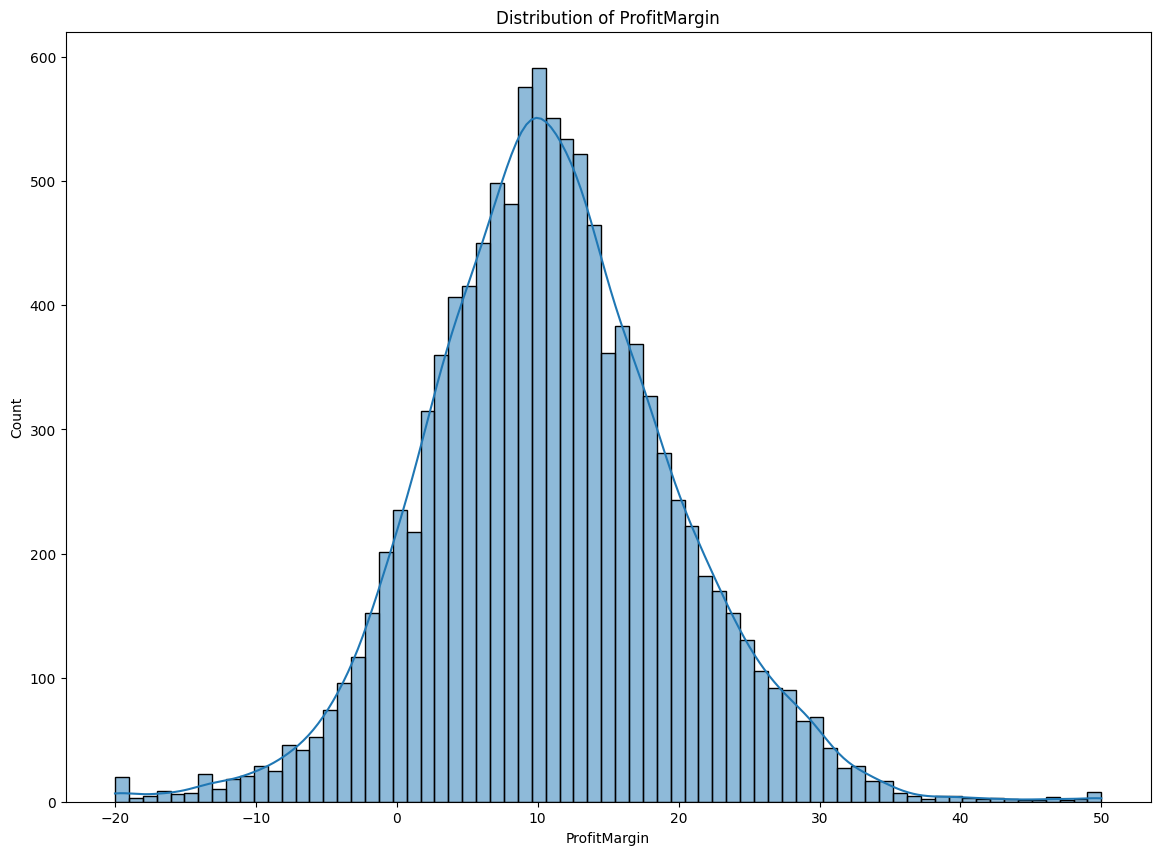

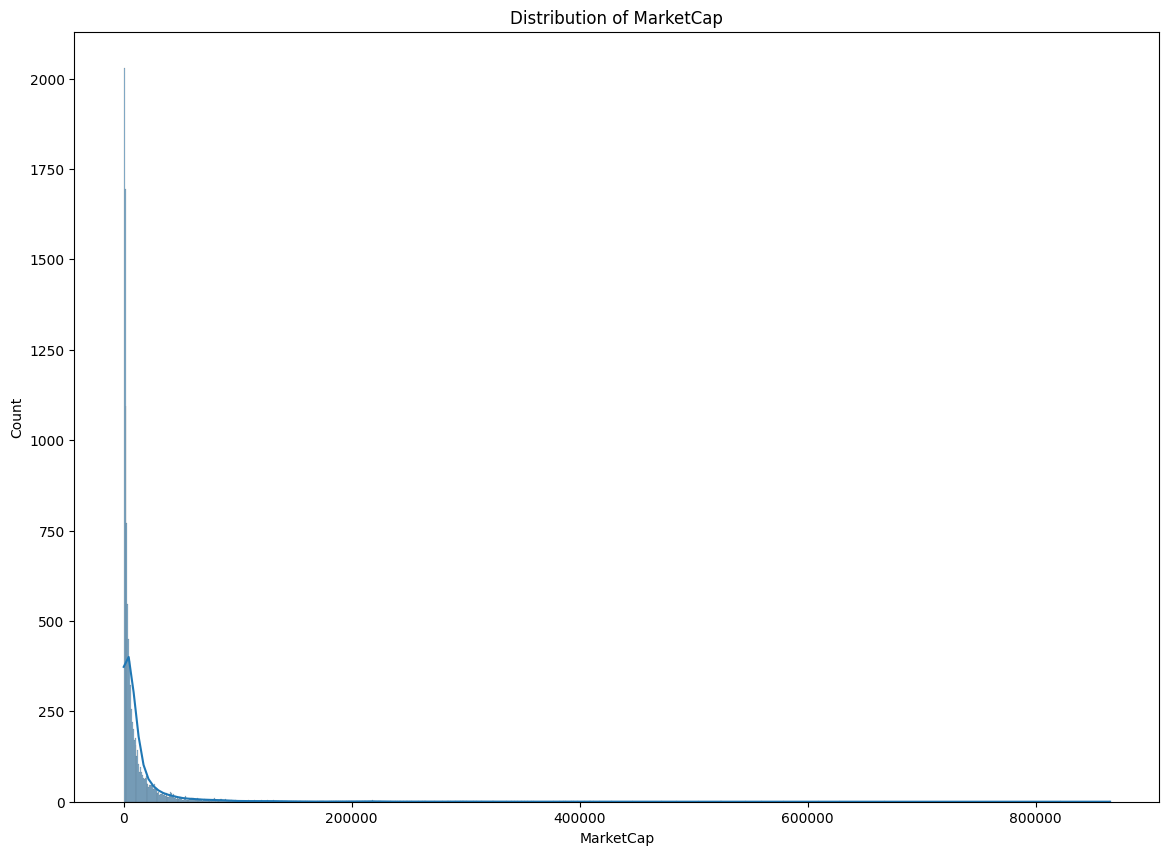

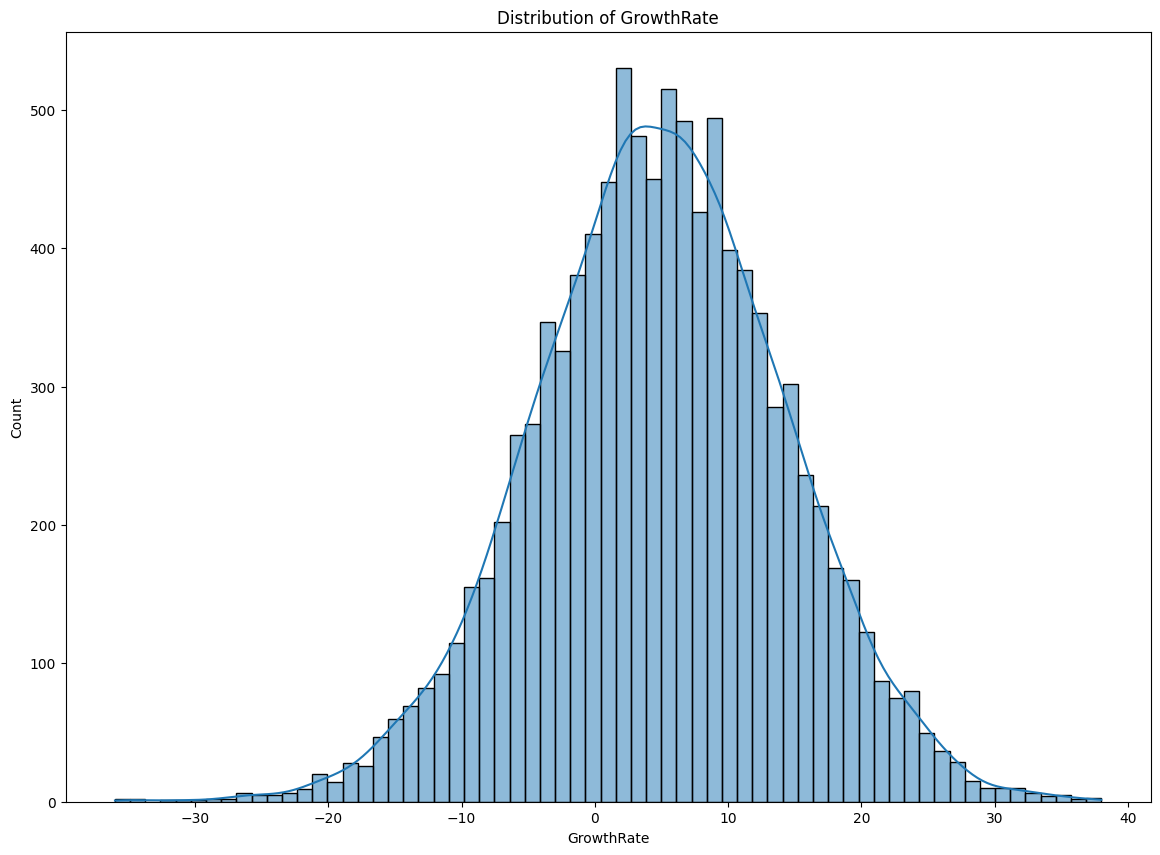

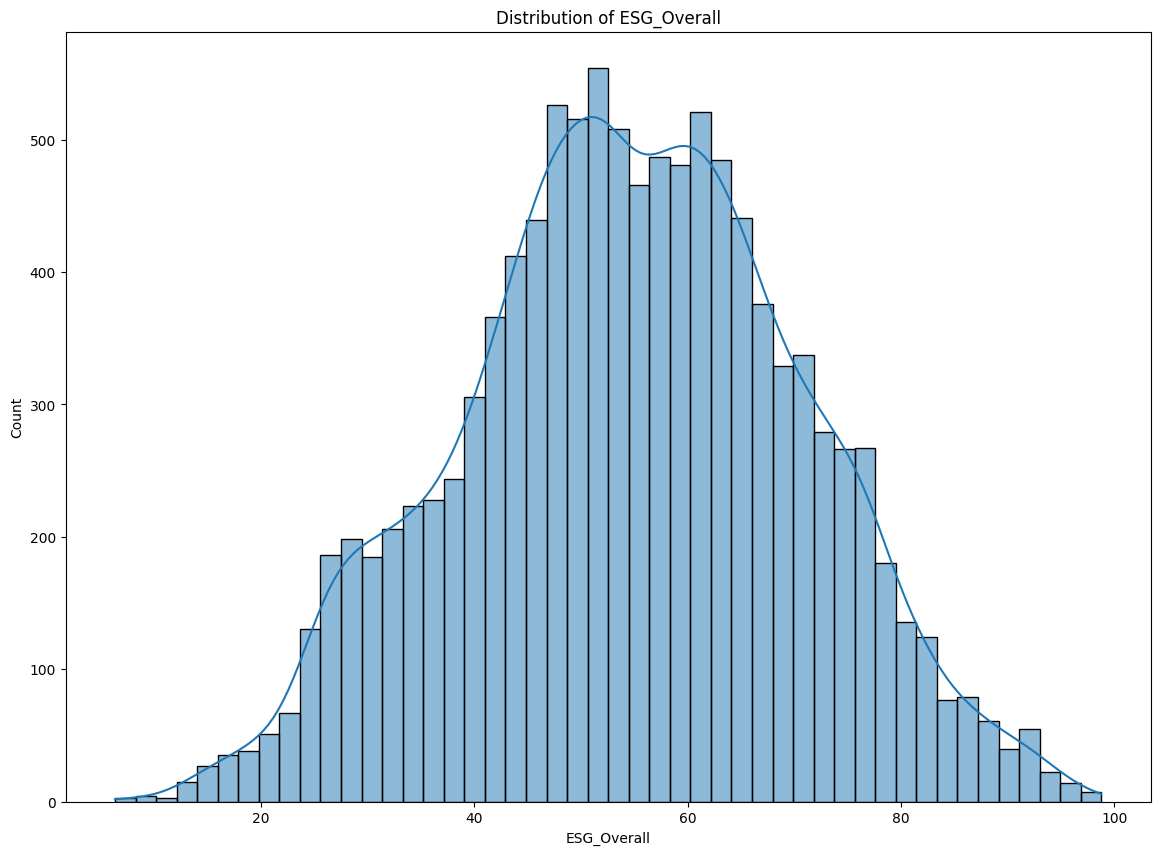

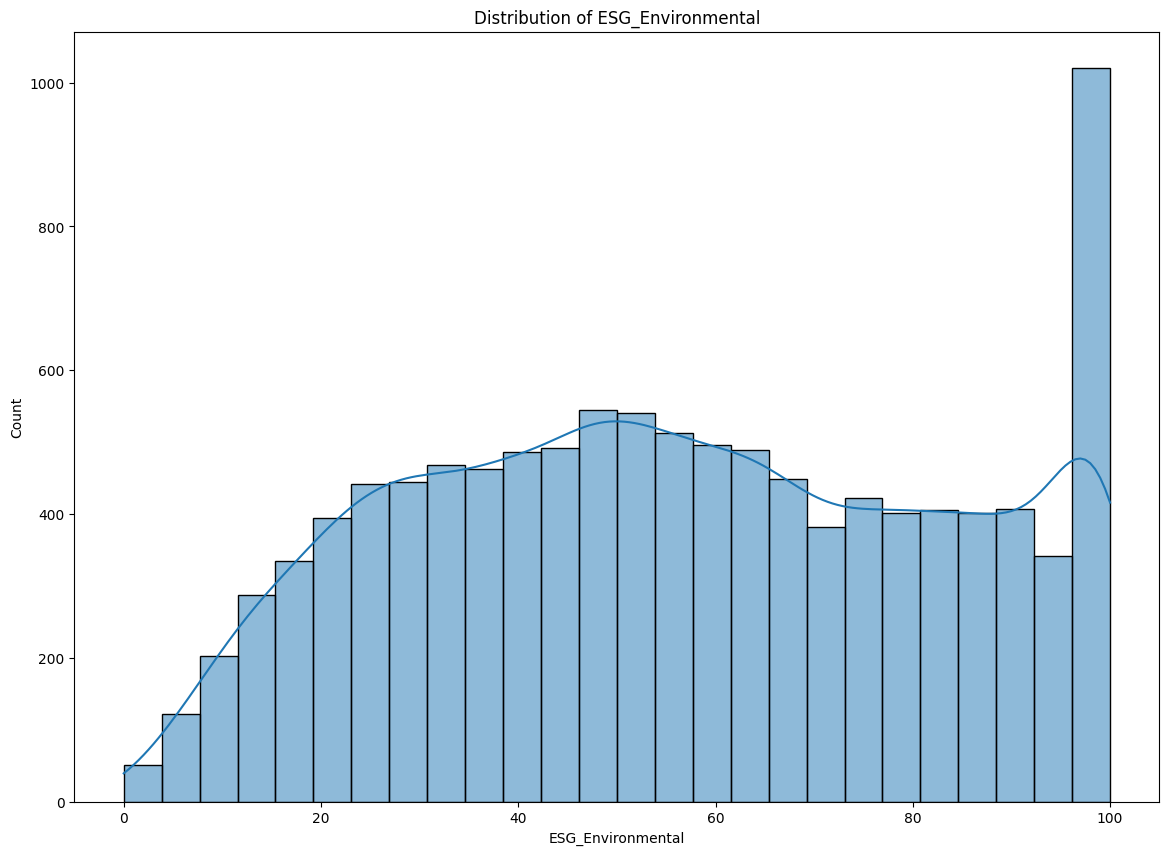

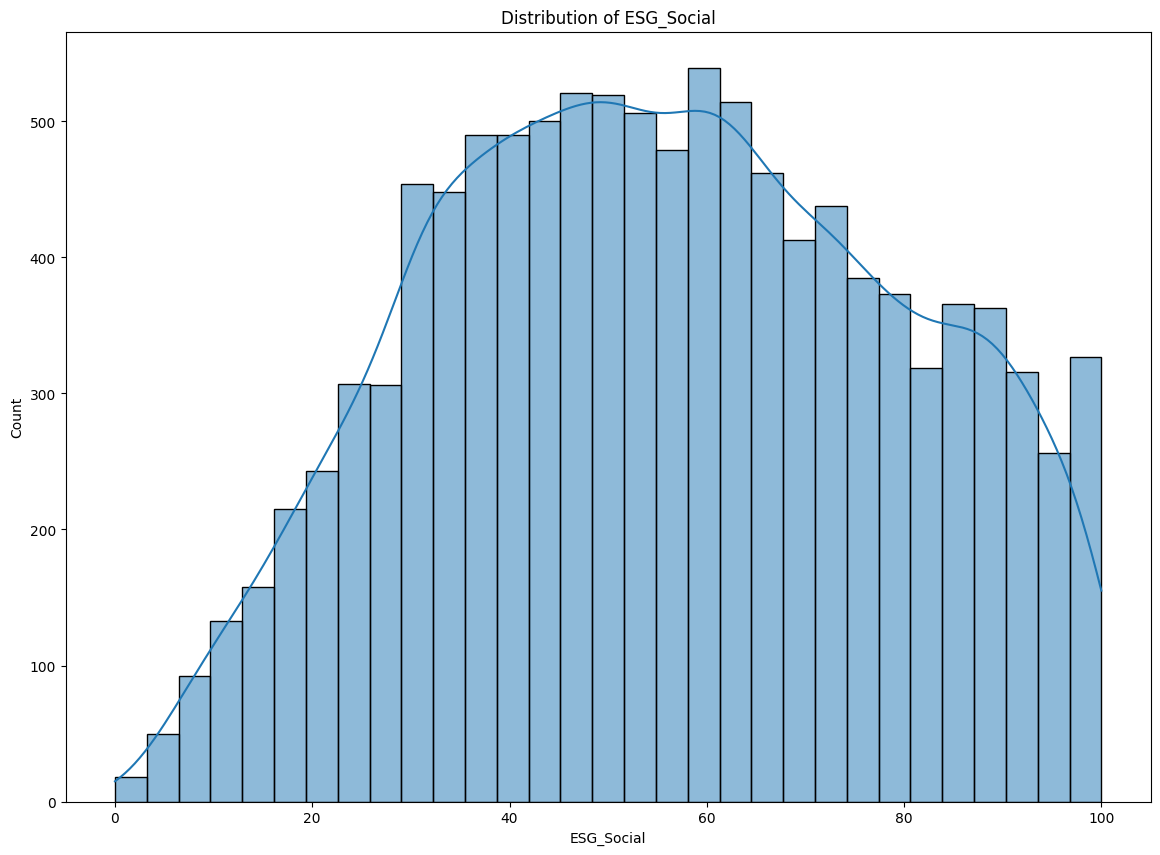

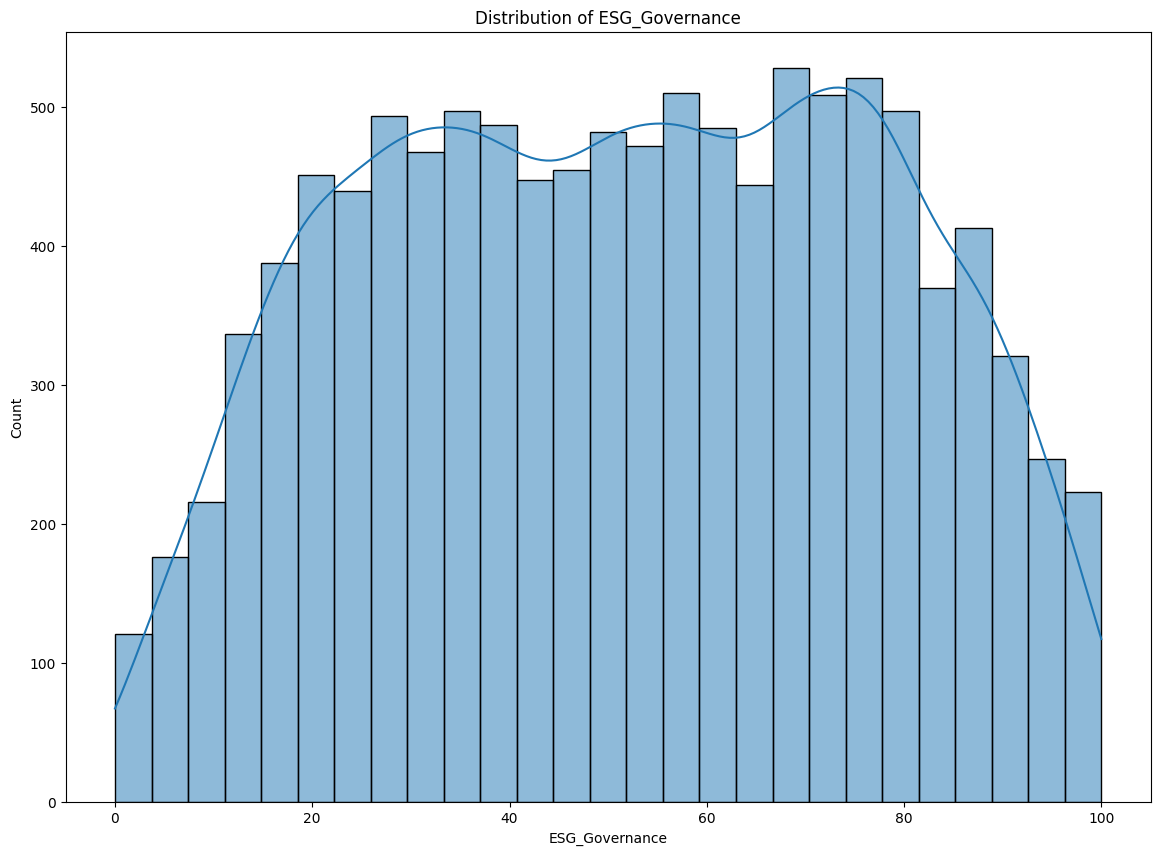

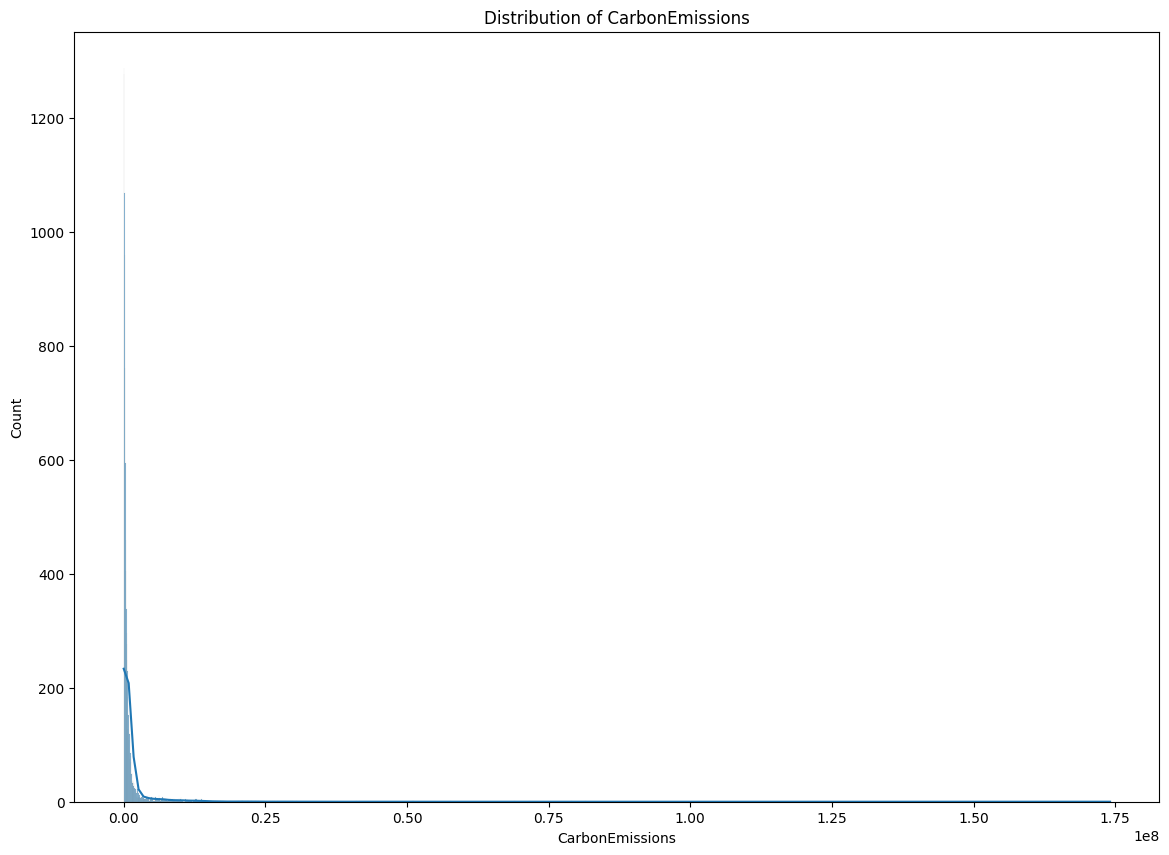

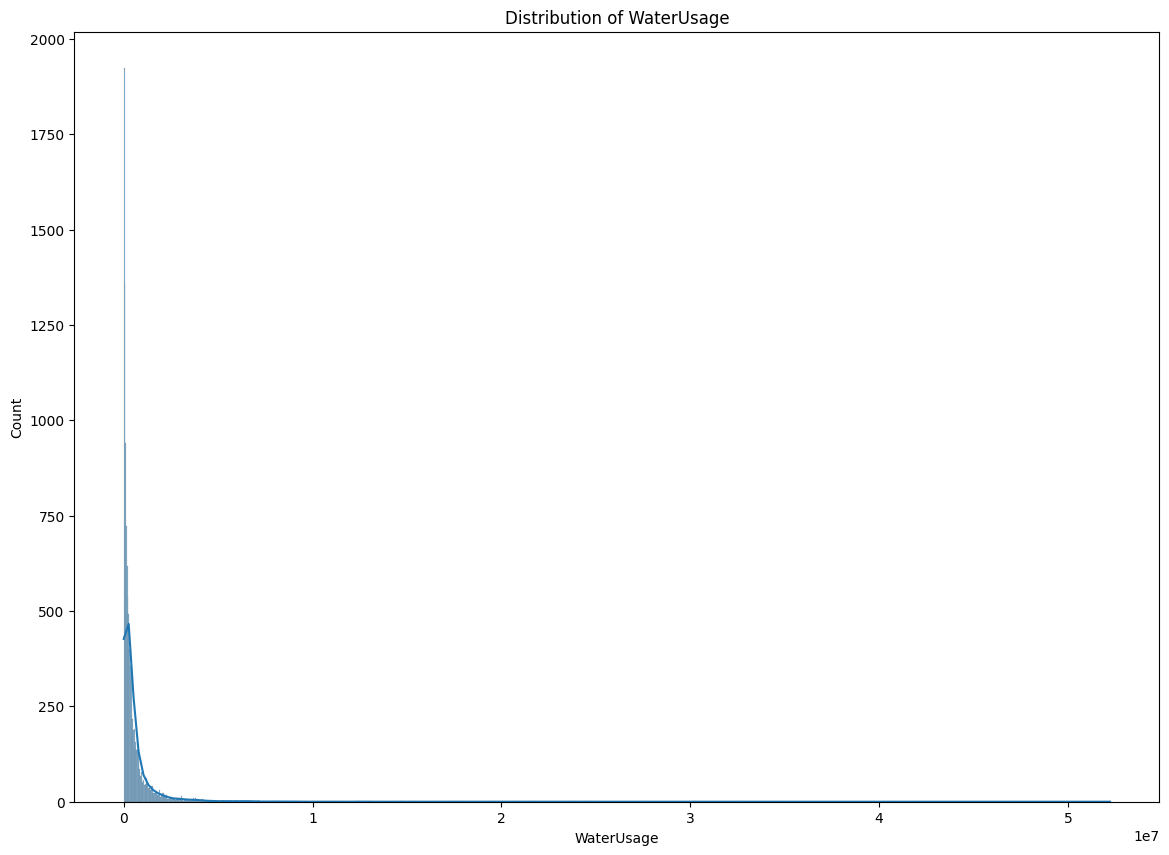

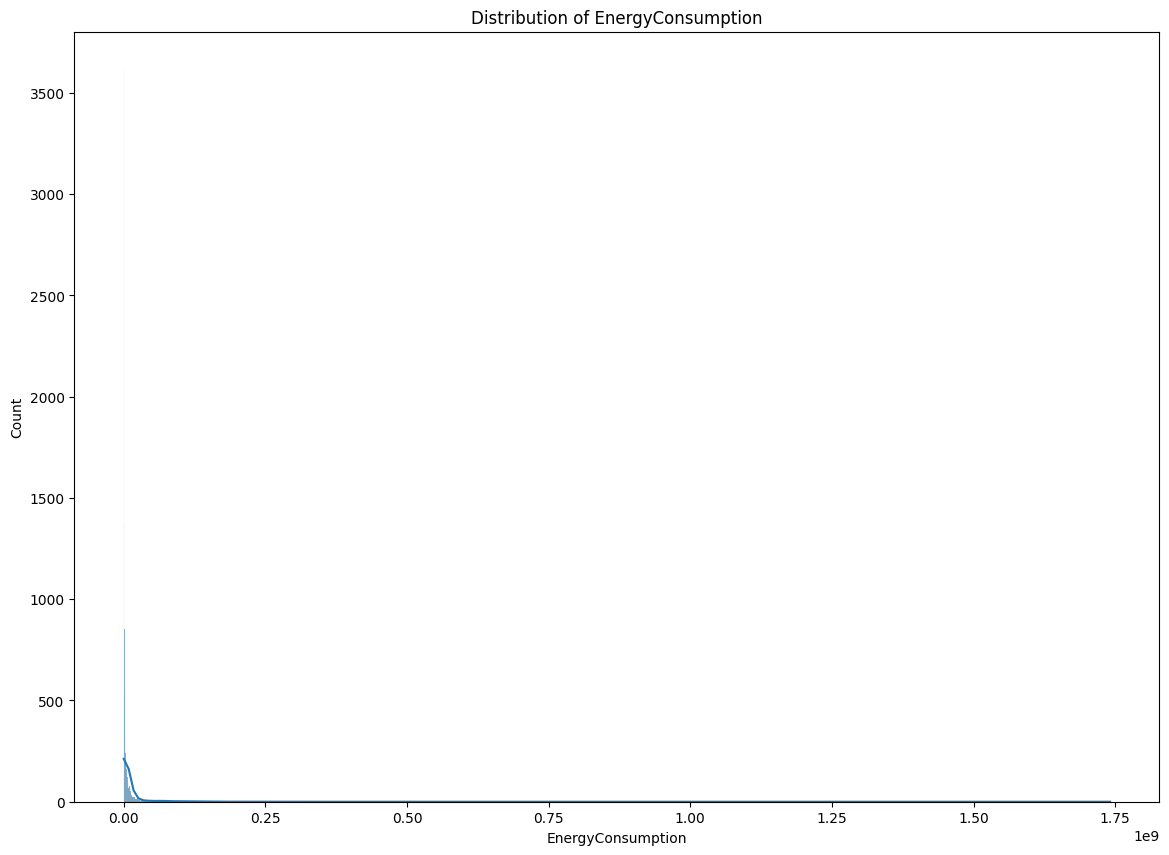

In [7]:
#Univariate Analysis
for col in categorical_cols:
    plt.figure(figsize=(14,10))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()

for col in numerical_cols:
    plt.figure(figsize=(14,10))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

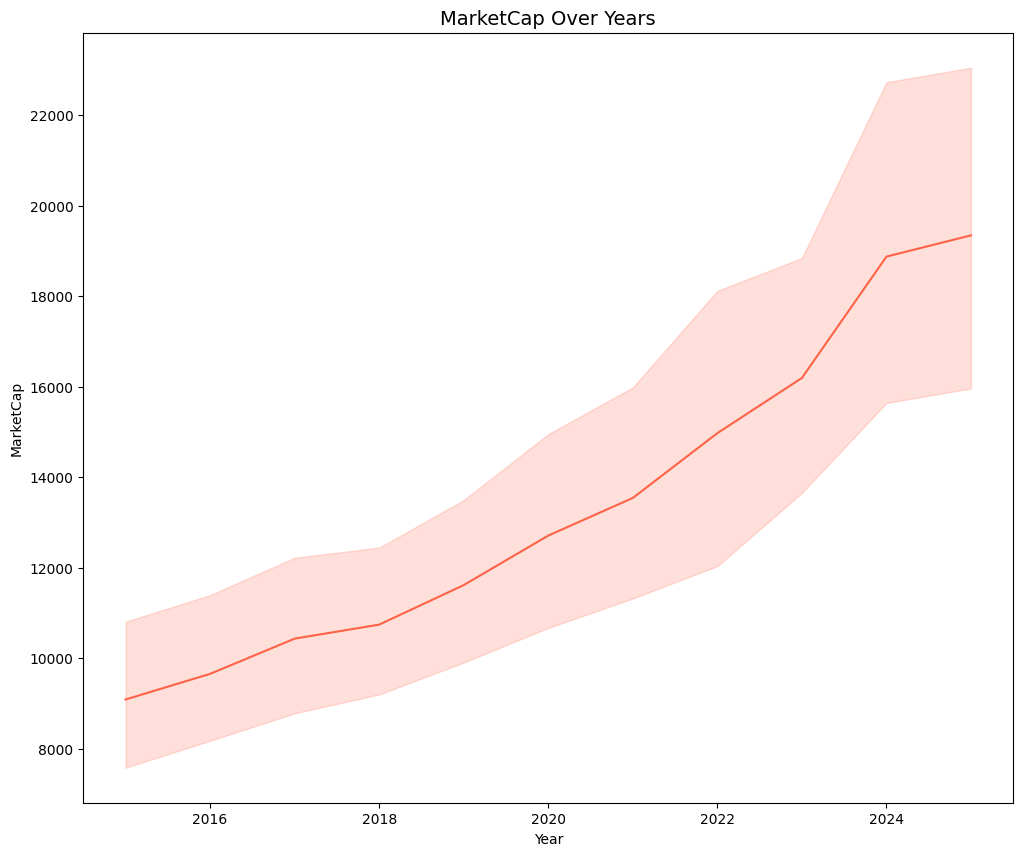

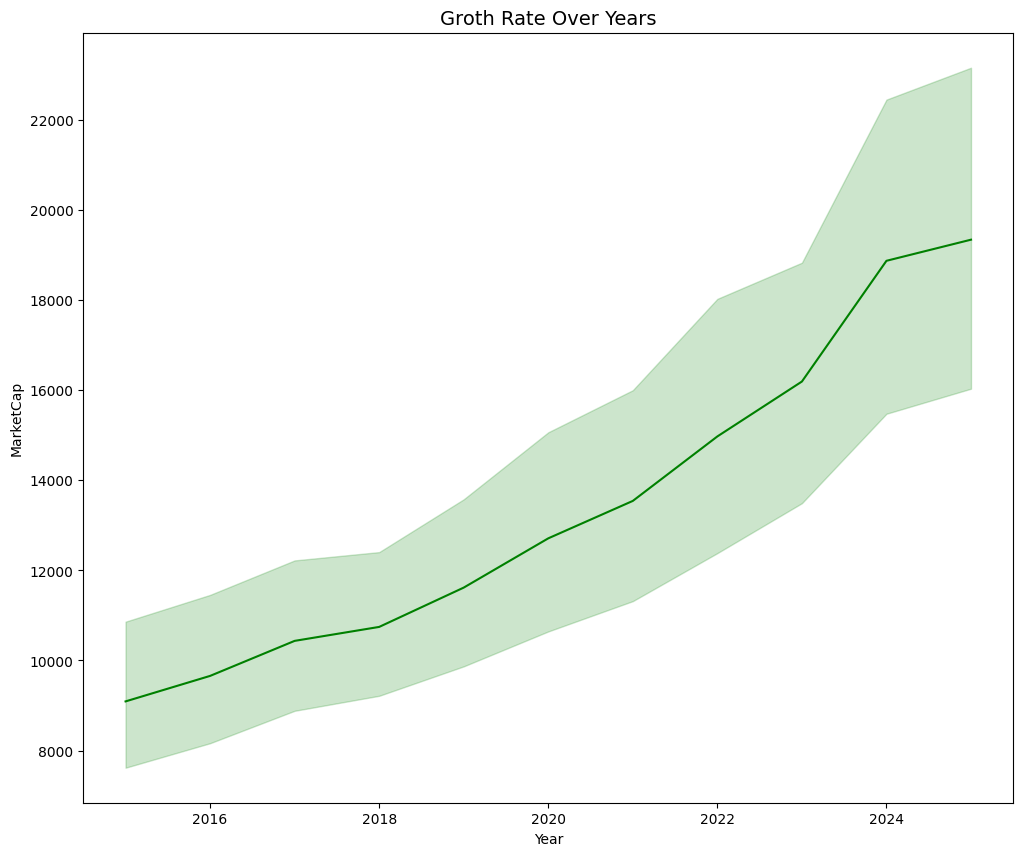

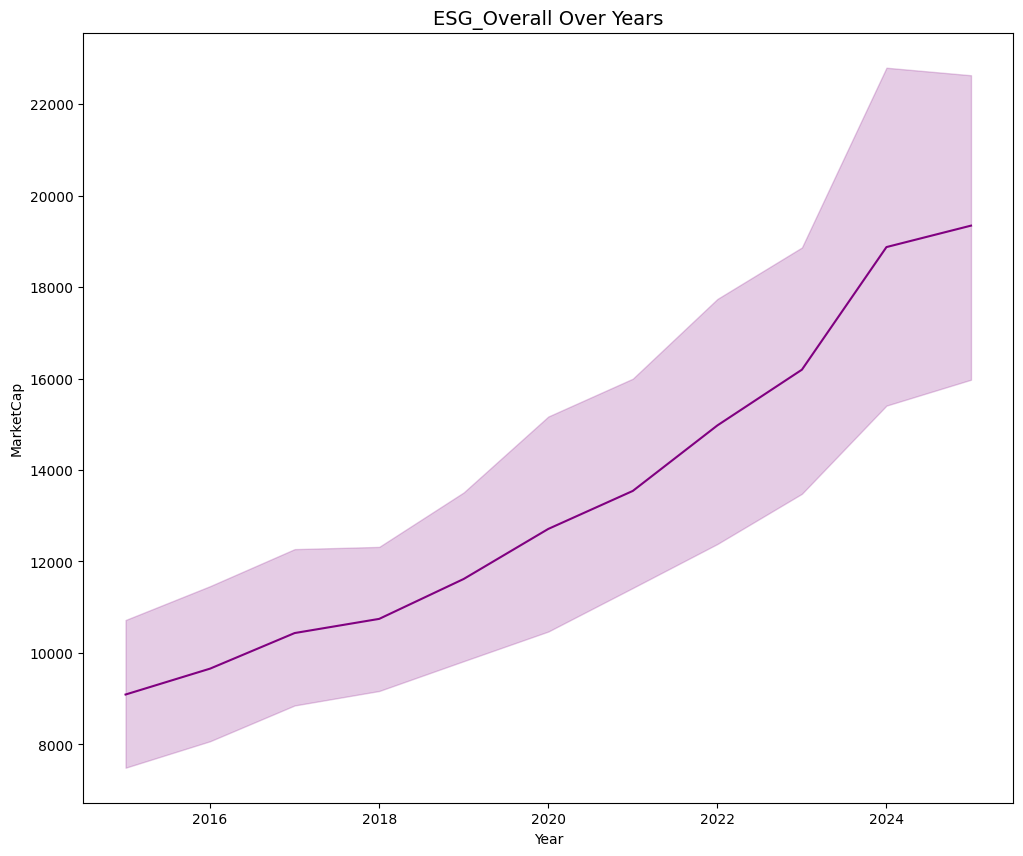

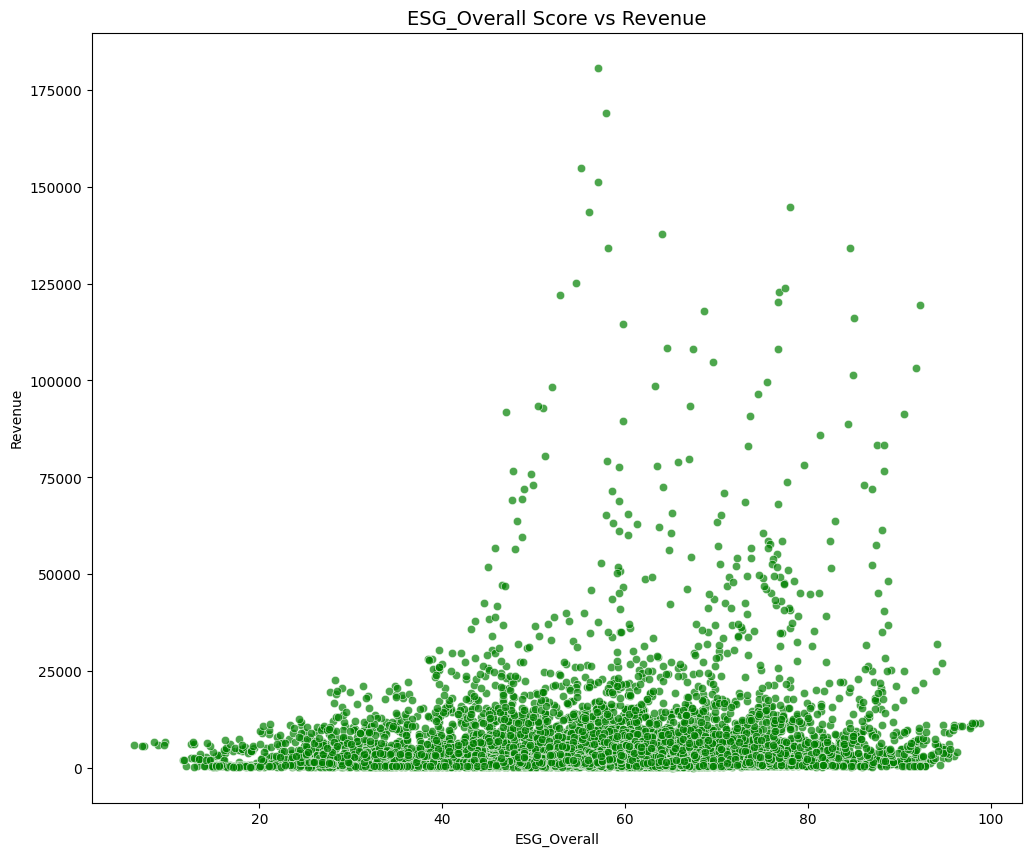

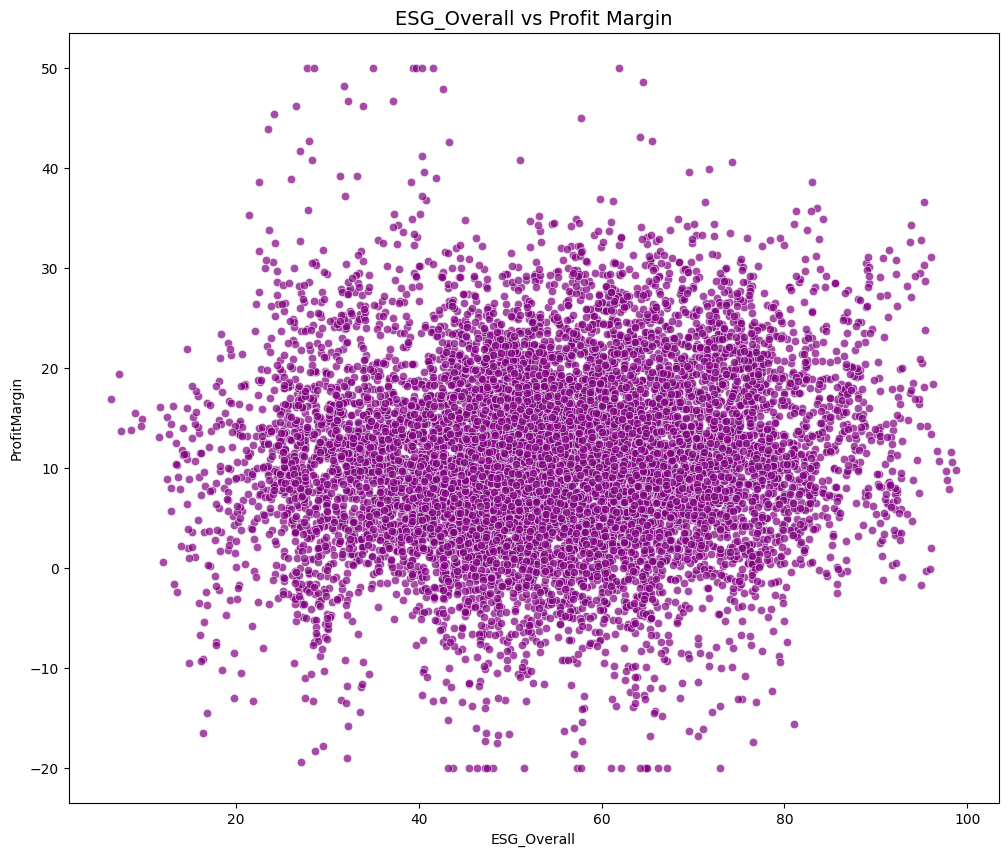

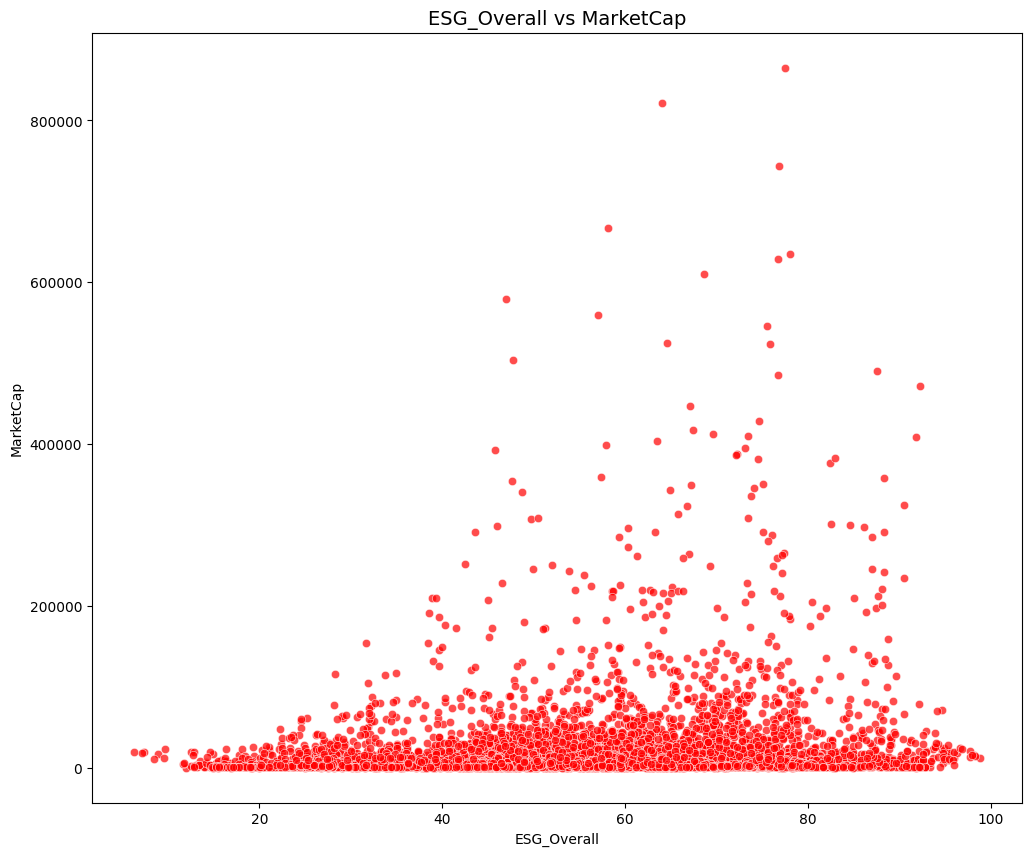

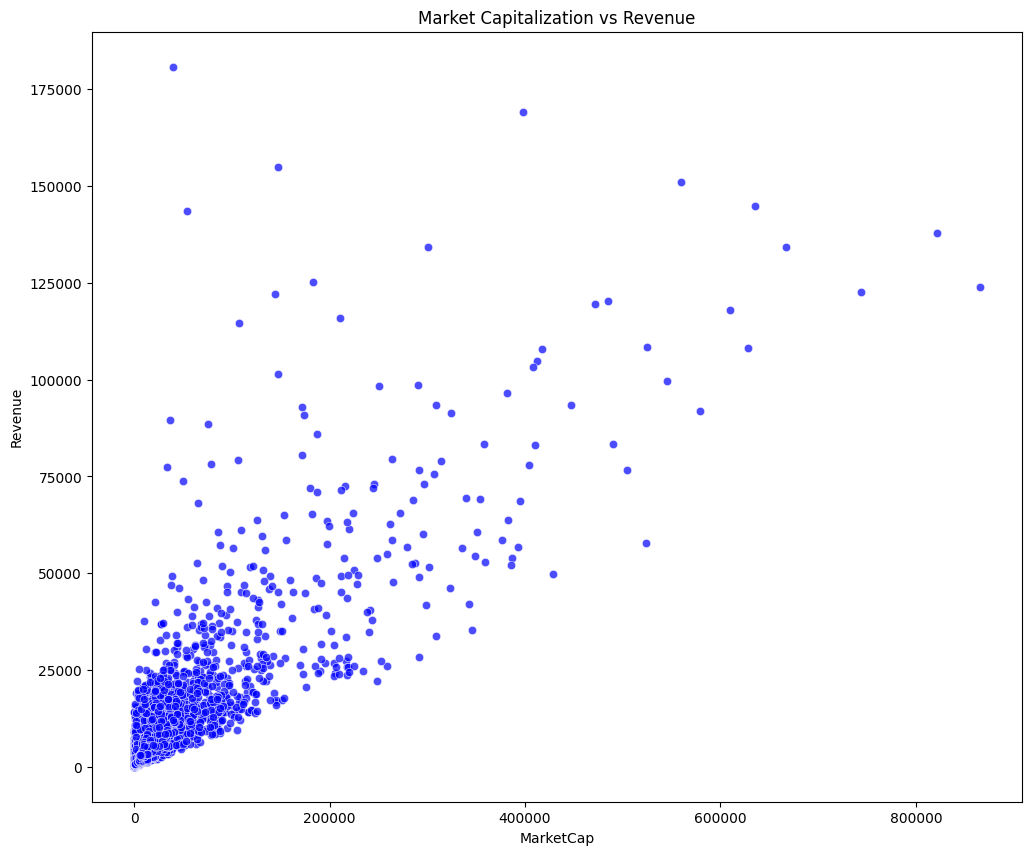

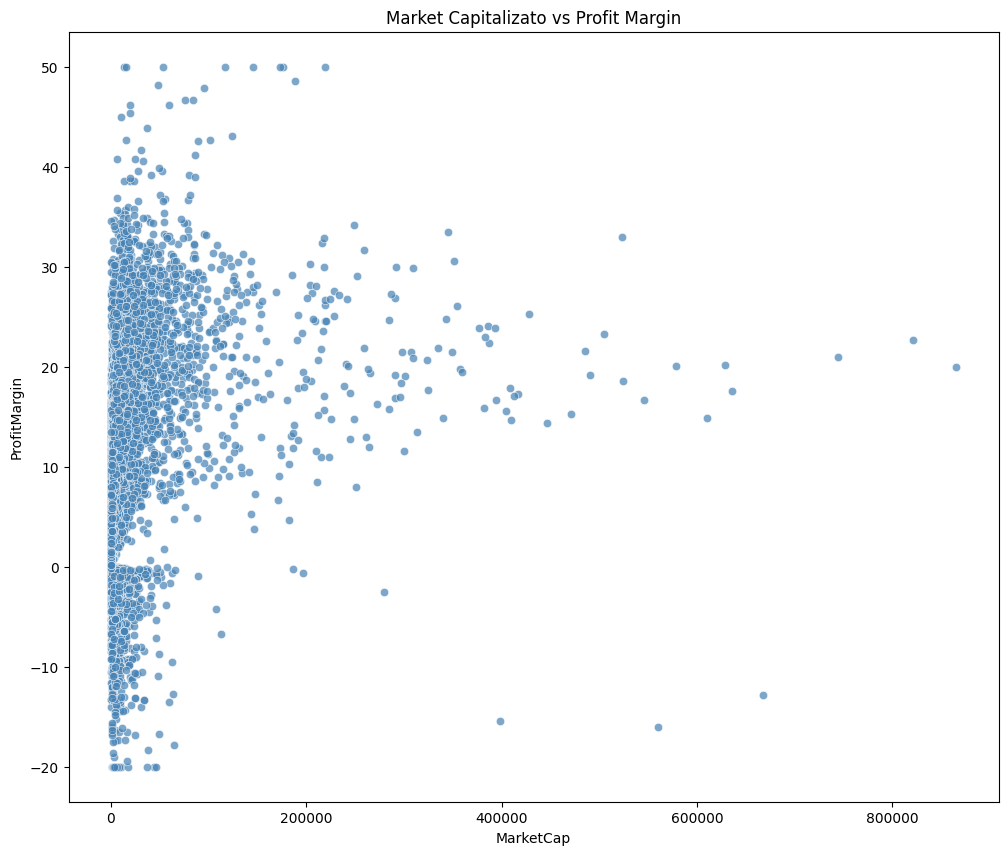

In [8]:
#Bivariate Analysis: Target vs Features
plt.figure(figsize=(12,10))
plt.title('MarketCap Over Years', fontsize=14)
sns.lineplot(x=df['Year'], y=df['MarketCap'], color='tomato')
plt.show()

plt.figure(figsize=(12,10))
plt.title('Groth Rate Over Years', fontsize=14)
sns.lineplot(x=df['Year'], y=df['MarketCap'], color='green')
plt.show()

plt.figure(figsize=(12,10))
plt.title('ESG_Overall Over Years', fontsize=14)
sns.lineplot(x=df['Year'], y=df['MarketCap'], color='purple')
plt.show()

plt.figure(figsize=(12,10))
plt.title('ESG_Overall Score vs Revenue', fontsize=14)
sns.scatterplot(x=df['ESG_Overall'], y=df['Revenue'], color='green', alpha=0.7)
plt.show()

plt.figure(figsize=(12,10))
plt.title('ESG_Overall vs Profit Margin', fontsize=14)
sns.scatterplot(x=df['ESG_Overall'], y=df['ProfitMargin'], color='purple', alpha=0.7)
plt.show()

plt.figure(figsize=(12,10))
plt.title('ESG_Overall vs MarketCap', fontsize=14)
sns.scatterplot(x=df['ESG_Overall'], y=df['MarketCap'], color='r', alpha=0.7)
plt.show()

plt.figure(figsize=(12,10))
plt.title('Market Capitalization vs Revenue')
sns.scatterplot(x=df['MarketCap'], y=df['Revenue'], color='b', alpha=0.7)
plt.show()

plt.figure(figsize=(12,10))
plt.title('Market Capitalizato vs Profit Margin')
sns.scatterplot(x=df['MarketCap'], y=df['ProfitMargin'], color='steelblue', alpha=0.7)
plt.show()

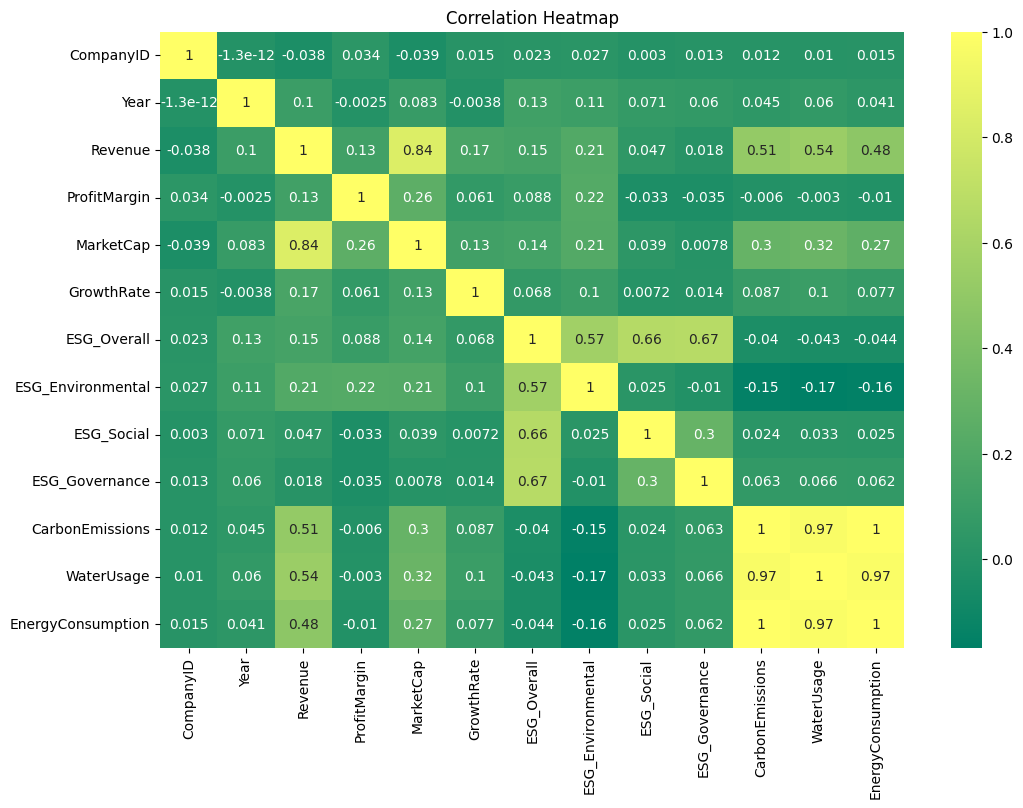

In [9]:
#correlation and Multicolinearity
plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='summer')
plt.title('Correlation Heatmap')
plt.show()

In [10]:
#preprocessing
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [11]:
#Label Encoding and Scalling
target = 'MarketCap'
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

numerical_cols = [col for col in df.columns if col not in categorical_cols + [target]]

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [12]:
#train test split
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

In [14]:
import dagshub
import mlflow
mlflow.set_tracking_uri("https://dagshub.com/virajdeshmukh080818/ESG.mlflow")
dagshub.init(repo_owner='virajdeshmukh080818', repo_name='ESG', mlflow=True)
mlflow.set_experiment('Linear Regression BaseModel')

Initialized MLflow to track repo "virajdeshmukh080818/ESG"

Repository virajdeshmukh080818/ESG initialized!

<Experiment: artifact_location='mlflow-artifacts:/3ca0b6b2db434b528253070be5b4bdd4', creation_time=1754681480757, experiment_id='0', last_update_time=1754681480757, lifecycle_stage='active', name='Linear Regression BaseModel', tags={}>

In [15]:
df.to_csv("processed_esg_dataset.csv", index=False)

In [16]:
import logging
import os
import time

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logging.info("Starting MLFlow Run -------->>>")

with mlflow.start_run():
    start_time = time.time()
    try:
        logging.info('Logging preprocessing parameters....')
        mlflow.log_param('test_size', 0.20)

        logging.info("InitializinG Linear Regression Model----->>>")
        model = LinearRegression()

        logging.info("Fitting the MODEL------->>>")
        model.fit(X_train, y_train)
        logging.info('Model Training Completed')

        logging.info('Logging Model Parameters---->>>')
        mlflow.log_param('model', 'LinearRegression')

        logging.info('Making Predictions---->>>')
        y_pred = model.predict(X_test)

        logging.info('Calculatiing Evaluation Metrics----->>>>')
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        

        logging.info('Logging Evaluation Metrics----->>>>>')
        mlflow.log_metric('Mean_squared_Error', mse)
        mlflow.log_metric('Mean abs Error', mae)
        mlflow.log_metric('Root_mean_squared_error', rmse)
        mlflow.log_metric('R2_Score', r2)
        

        logging.info('Saving and logging the Model----->>>')
        mlflow.sklearn.log_model(model, name='model')

        end_time = time.time()
        logging.info(f'Model Training and Logging Completed in {end_time - start_time}')

        
        logging.info(f'MSE: {mse}')
        logging.info(f'MAE: {mae}')
        logging.info(f'RMSE: {rmse}')
        logging.info(f'r2_score: {r2}')
        

    except Exception as e:
        logging.error(f"An Error Occured: {e}", exc_info=True)
        


2025-10-01 11:33:37,378 - INFO - Starting MLFlow Run -------->>>
2025-10-01 11:33:38,776 - INFO - Logging preprocessing parameters....
2025-10-01 11:33:39,209 - INFO - InitializinG Linear Regression Model----->>>
2025-10-01 11:33:39,210 - INFO - Fitting the MODEL------->>>
2025-10-01 11:33:39,234 - INFO - Model Training Completed
2025-10-01 11:33:39,235 - INFO - Logging Model Parameters---->>>
2025-10-01 11:33:39,639 - INFO - Making Predictions---->>>
2025-10-01 11:33:39,639 - INFO - Calculatiing Evaluation Metrics----->>>>
2025-10-01 11:33:39,639 - INFO - Logging Evaluation Metrics----->>>>>
2025-10-01 11:33:44,988 - INFO - Saving and logging the Model----->>>
2025-10-01 11:33:45,894 - ERROR - An Error Occured: INTERNAL_ERROR: Response: {'error': 'unsupported endpoint, please contact support@dagshub.com'}
Traceback (most recent call last):
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_7176\2970750856.py", line 42, in <module>
    mlflow.sklearn.log_model(model, name='model')
  F

🏃 View run rambunctious-ray-722 at: https://dagshub.com/virajdeshmukh080818/ESG.mlflow/#/experiments/0/runs/ca2b734086b5486ca4a73912244e382a
🧪 View experiment at: https://dagshub.com/virajdeshmukh080818/ESG.mlflow/#/experiments/0
